# 전체 코드 흐름 개요 (SVM + GridSearchCV 하이퍼파라미터 튜닝)

이 노트북은 **SVM(LinearSVC) 학습/평가** 후, **GridSearchCV 기반 하이퍼파라미터 튜닝**을 통해
디지털 소외계층을 3단계로 분류하는 파이프라인을 구현한다.

---
## 1) 파이프라인 단계

**단계 1. 환경/재현성/경로 초기화**
- 환경변수 우선, 없으면 자동 탐색 (MLP·LightGBM과 동일)

**단계 2. 데이터 로딩 및 라벨 정규화**
- 레이블 1/2/3 → 0/1/2 변환

**단계 3. Baseline SVM 학습**
- 기본 C=1.0으로 학습해 튜닝 전 기준점 확인

**단계 4. GridSearchCV 하이퍼파라미터 튜닝**
- C 값 탐색 + loss 함수 탐색 (5-Fold Stratified CV)
- 학습 비용 절감: GridSearch 단계에서 CalibratedClassifierCV 제외
  → 최적 C 확정 후 마지막 1회만 calibration 수행

**단계 5. 최종 모델 학습 (Calibration 적용)**
- 최적 C로 LinearSVC 학습
- CalibratedClassifierCV로 확률 추출 가능하게 함

**단계 6. val/test 평가**

**단계 7. 시각화**
- GridSearch C 탐색 곡선
- Test Set 예측 결과 (Confusion Matrix / 분포 / 정답비율)

**단계 8. Feature Weight 분석**
- coef 기반 + Permutation Importance(val 기준)

---
## 2) SVM 설계 결정 사항

| 항목 | 선택 | 이유 |
|------|------|------|
| `LinearSVC` | ✅ | 18,799개 샘플에서 커널 SVM은 O(n²~n³)으로 너무 느림 |
| `StandardScaler` | ✅ | SVM은 feature 스케일에 민감 → 필수 |
| `class_weight='balanced'` | ✅ | 클래스 불균형(5,037~7,081) 보정 |
| GridSearch → Calibration 분리 | ✅ | 기존 구조(CalibratedCV 안에 GridSearch)는 5×3=15배 비용 |

## 3) 주요 산출물
- `svm_gridsearch_curve.png`          # C 탐색 곡선
- `svm_prediction_results.png`        # Test Set 예측 결과
- `SVM_evaluation.txt`                # val/test 성능 리포트
- `svm_feature_weights.png`           # coef + Permutation Importance
- `svm_feature_weights.csv`           # feature 중요도 수치
- `svm_gridsearch_results.csv`        # GridSearch 결과
- `svm_summary.json`                  # 최종 성능 요약


## [단계 1] 환경/재현성/경로 초기화

In [ ]:
# ____________________________________________________________
# [파이프라인 단계 1] 환경/재현성/경로 초기화
# ____________________________________________________________

from pathlib import Path
import os, sys, warnings, json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')

# 한글 폰트 설정 (모든 OS 대응, MLP·LightGBM과 동일 방식)
for font in ['Malgun Gothic', 'AppleGothic', 'NanumGothic']:
    if font in {f.name for f in fm.fontManager.ttflist}:
        plt.rcParams['font.family'] = font
        break
plt.rcParams['axes.unicode_minus'] = False

# 환경변수 PROJECT_ROOT가 있으면 우선 사용, 없으면 현재 디렉토리부터 탐색
def find_project_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if ((candidate / '.git').exists() or (candidate / 'notebooks').exists()) \
                and (candidate / 'data').exists():
            return candidate
    raise FileNotFoundError('Project root not found.')

PROJECT_ROOT = (
    Path(os.environ['PROJECT_ROOT']).expanduser().resolve()
    if 'PROJECT_ROOT' in os.environ
    else find_project_root(Path.cwd())
)

DATA_DIR   = PROJECT_ROOT / 'data' / 'labeled'
OUTPUT_DIR = PROJECT_ROOT / 'models' / 'SVM'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for name in ['train_labeled.csv', 'val_labeled.csv', 'test_labeled.csv']:
    if not (DATA_DIR / name).exists():
        raise FileNotFoundError(f'Missing: {DATA_DIR / name}')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from models.model_config import MODEL_FEATURES, TARGET_COL, EVAL_METRICS, evaluate

SEED = 42
CLASS_NAMES = ['1단계_완전소외', '2단계_부분적응', '3단계_자립적응']

print('Project root:', PROJECT_ROOT)
print('Output dir  :', OUTPUT_DIR)
print('Features    :', len(MODEL_FEATURES), '/ Target:', TARGET_COL)
print('Eval metrics:', EVAL_METRICS)


Project root: C:\Users\user\Desktop\260608_기계학습기초 팀플 - 복사본\Team-3
Output dir  : C:\Users\user\Desktop\260608_기계학습기초 팀플 - 복사본\Team-3\models\SVM
Features    : 118 / Target: digital_stage
Eval metrics: ('accuracy', 'macro_f1', 'weighted_f1')


## [단계 2] 데이터 로딩 및 라벨 정규화

In [ ]:
# ____________________________________________________________
# [파이프라인 단계 2] 데이터 로딩 및 라벨 정규화
# ____________________________________________________________

train_df = pd.read_csv(DATA_DIR / 'train_labeled.csv')
val_df   = pd.read_csv(DATA_DIR / 'val_labeled.csv')
test_df  = pd.read_csv(DATA_DIR / 'test_labeled.csv')

for df in [train_df, val_df, test_df]:
    df['digital_stage'] -= 1  # 1/2/3 → 0/1/2 (MLP·LightGBM과 동일)

X_train = train_df[MODEL_FEATURES].values.astype('float32')
y_train = train_df[TARGET_COL].values.astype('int32')
X_val   = val_df[MODEL_FEATURES].values.astype('float32')
y_val   = val_df[TARGET_COL].values.astype('int32')
X_test  = test_df[MODEL_FEATURES].values.astype('float32')
y_test  = test_df[TARGET_COL].values.astype('int32')

print(f'train : {X_train.shape}  클래스 분포: {np.bincount(y_train)}')
print(f'val   : {X_val.shape}   클래스 분포: {np.bincount(y_val)}')
print(f'test  : {X_test.shape}  클래스 분포: {np.bincount(y_test)}')
train_df.head()


train : (18799, 118)  클래스 분포: [6681 7081 5037]
val   : (6267, 118)   클래스 분포: [2294 2273 1700]
test  : (6267, 118)  클래스 분포: [2238 2341 1688]


,row_id,GROUP,YEAR,Q1_1,Q1_2,Q2K2_1,Q2K2_2,Q3,Q4B_1_1,Q4B_2_1,...,연령,성별,직업,학력,가구구성형태,가구소득,거주지역,cluster,digital_stage,digital_stage_name
0,0,장애인,2025,0,0,0,0,1,0,0,...,6.0,1.0,14.0,3.0,1.0,1.0,9.0,1,0,1단계_완전_소외
1,1,일반국민,2025,1,0,0,0,1,1,1,...,2.0,2.0,4.0,4.0,1.0,7.0,2.0,2,2,3단계_자립_적응
2,2,일반국민,2024,1,1,1,1,1,0,0,...,44.0,2.0,11.0,4.0,2.0,5.0,1.0,2,2,3단계_자립_적응
3,3,농어민,2024,0,0,0,0,1,0,0,...,59.0,1.0,6.0,3.0,2.0,3.0,14.0,1,0,1단계_완전_소외
4,4,일반국민,2024,0,0,1,0,1,1,0,...,48.0,1.0,8.0,3.0,2.0,5.0,2.0,0,1,2단계_부분_적응


## [단계 3] Baseline SVM 학습

튜닝 전 기본 파라미터(C=1.0)로 학습해 기준점을 확인한다.


In [ ]:
# ____________________________________________________________
# [파이프라인 단계 3] Baseline SVM 학습
# ____________________________________________________________

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

baseline_svc = LinearSVC(C=1.0, class_weight='balanced',
                          max_iter=3000, random_state=SEED)
baseline_svc.fit(X_train_scaled, y_train)

baseline_val_pred  = baseline_svc.predict(X_val_scaled)
baseline_test_pred = baseline_svc.predict(X_test_scaled)

baseline_val_f1  = f1_score(y_val,  baseline_val_pred,  average='macro')
baseline_test_f1 = f1_score(y_test, baseline_test_pred, average='macro')

print('=== Baseline 성능 (C=1.0) ===')
print(f'Val  F1-macro : {baseline_val_f1:.4f}')
print(f'Test Accuracy : {accuracy_score(y_test, baseline_test_pred):.4f}')
print(f'Test F1-macro : {baseline_test_f1:.4f}')


=== Baseline 성능 (C=1.0) ===
Val  F1-macro : 0.9896
Test Accuracy : 0.9861
Test F1-macro : 0.9861


## [단계 4] GridSearchCV 하이퍼파라미터 튜닝

### SVM 핵심 파라미터: C (정규화 강도)

C는 SVM에서 가장 중요한 하이퍼파라미터다:

| C 값 | 의미 | 특징 |
|------|------|------|
| **작은 C** | 강한 정규화 | 마진을 크게 유지, 오분류 허용, 과적합 방지 |
| **큰 C** | 약한 정규화 | 오분류를 최소화, 마진이 좁아짐, 과적합 위험 |

### 학습 비용 절감 설계

기존 구조: `GridSearchCV(CalibratedClassifierCV(LinearSVC))` → 5×5×3 = **75회** 학습  
개선 구조: `GridSearchCV(LinearSVC)` → 5×5 = **25회** 학습, 이후 Calibration **1회**  

> 최적 C 탐색 단계에서는 확률값이 필요없으므로 CalibratedClassifierCV를 제외한다.
> 확률 출력이 필요한 calibration은 최적 C 확정 후 마지막에 1회만 수행한다.


In [ ]:
# ____________________________________________________________
# [파이프라인 단계 4] GridSearchCV 하이퍼파라미터 튜닝
# ____________________________________________________________

# GridSearch 단계: LinearSVC만 사용 (Calibration 제외로 학습 비용 절감)
# 5 C값 × 5-Fold = 25회 학습 (기존 75회 대비 1/3)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

grid_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LinearSVC(class_weight='balanced', max_iter=3000, random_state=SEED)),
])

param_grid = {
    # C 상한 100→1000으로 확장:
    # 기존 최적값이 C=100(상한)에 걸려있었으므로 더 큰 값도 탐색
    'clf__C':    [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
    # loss 함수 추가:
    # hinge         → 표준 SVM 손실. 마진 경계에서 선형 감소
    # squared_hinge → hinge의 제곱. 이상치에 더 민감하지만 수렴이 빠름
    # 데이터 특성에 따라 성능 차이가 날 수 있음
    'clf__loss': ['hinge', 'squared_hinge'],
}

grid_search = GridSearchCV(
    grid_pipeline, param_grid,
    cv=cv, scoring='f1_macro',
    n_jobs=-1, verbose=1, refit=True,
)

print('GridSearchCV 시작 (C: 0.01/0.1/1/10/100/1000  |  loss: hinge/squared_hinge)...')
print(f'총 학습 횟수: {len([0.01,0.1,1,10,100,1000]) * 2} 조합 × 5 Fold = {len([0.01,0.1,1,10,100,1000]) * 2 * 5}회')
grid_search.fit(X_train, y_train)

best_C    = grid_search.best_params_['clf__C']
best_loss = grid_search.best_params_['clf__loss']
best_cv_f1 = grid_search.best_score_

print(f'\n최적 C      : {best_C}')
print(f'최적 loss   : {best_loss}')
print(f'CV F1-macro : {best_cv_f1:.4f}  (Baseline val: {baseline_val_f1:.4f})')

# GridSearch 결과 저장
cv_df = pd.DataFrame(grid_search.cv_results_)[
    ['param_clf__C', 'mean_test_score', 'std_test_score', 'rank_test_score']
].rename(columns={
    'param_clf__C':   'C',
    'mean_test_score': 'mean_f1_macro',
    'std_test_score':  'std_f1_macro',
    'rank_test_score': 'rank',
})
cv_df.to_csv(OUTPUT_DIR / 'svm_gridsearch_results.csv', index=False)
display(cv_df)


GridSearchCV 시작 (C: 0.01/0.1/1/10/100/1000  |  loss: hinge/squared_hinge)...
총 학습 횟수: 12 조합 × 5 Fold = 60회
Fitting 5 folds for each of 12 candidates, totalling 60 fits

최적 C      : 1000.0
최적 loss   : squared_hinge
CV F1-macro : 0.9927  (Baseline val: 0.9896)


,C,mean_f1_macro,std_f1_macro,rank
0,0.01,0.936381,0.003065,12
1,0.01,0.954962,0.003367,11
2,0.10,0.958832,0.001921,10
3,0.10,0.975943,0.002407,9
4,1.00,0.978440,0.002132,8
5,1.00,0.987493,0.001094,7
6,10.00,0.988131,0.001642,6
7,10.00,0.992117,0.000845,3
8,100.00,0.989736,0.001697,5
9,100.00,0.992617,0.001148,2


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

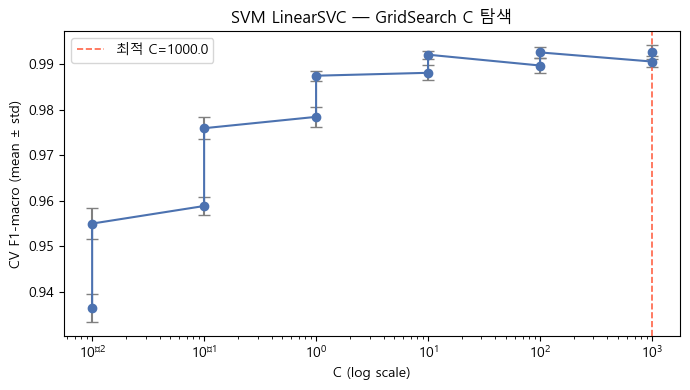

In [ ]:
# C 탐색 곡선 시각화
fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(
    cv_df['C'].astype(float),
    cv_df['mean_f1_macro'],
    yerr=cv_df['std_f1_macro'],
    marker='o', color='#4C72B0', ecolor='gray', capsize=4, linewidth=1.5,
)
ax.axvline(x=best_C, color='tomato', linestyle='--', linewidth=1.2,
           label=f'최적 C={best_C}')
ax.set_xscale('log')
ax.set_xlabel('C (log scale)')
ax.set_ylabel('CV F1-macro (mean ± std)')
ax.set_title('SVM LinearSVC — GridSearch C 탐색')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'svm_gridsearch_curve.png', dpi=150)
plt.show()


**C 탐색 결과 해석**
- C가 너무 작으면 모델이 단순해 underfitting, C가 너무 크면 과적합 위험
- 최적 C에서 CV F1-macro가 최고이며 std가 작을수록 안정적인 파라미터


## [단계 5] 최종 모델 학습 (Calibration 분리 적용)

GridSearch에서 찾은 최적 C로 LinearSVC를 학습한 뒤,  
CalibratedClassifierCV를 **별도로 1회** 적용해 확률 출력을 가능하게 한다.

> **왜 분리하는가?** GridSearch 내부에 CalibratedClassifierCV를 넣으면  
> 5-Fold CV × 3-Fold Calibration = 15배의 학습 비용이 발생한다.  
> 최적 C를 먼저 찾고 나서 1회만 calibration하면 동일한 결과를 훨씬 빠르게 얻는다.


In [ ]:
# ____________________________________________________________
# [파이프라인 단계 5] 최종 모델 학습 (Calibration 분리)
# ____________________________________________________________

# ── 분류용 모델: Pipeline(Scaler + LinearSVC) ────────────────
# Scaler를 Pipeline 안에 넣어 GridSearch와 동일한 구조 유지
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LinearSVC(C=best_C, loss=best_loss, class_weight='balanced',
                         max_iter=3000, random_state=SEED)),
])
final_pipeline.fit(X_train, y_train)

# ── 확률 출력용 모델: Pipeline 전체를 CalibratedClassifierCV로 감쌈 ──
# [수정] 기존: 전체 train을 먼저 스케일링 후 CalibratedCV 입력
#        → calibration 내부 CV fold의 val에 train 전체 통계가 반영 (누수)
# [개선] Scaler를 Pipeline 안에 포함해 raw X_train을 입력
#        → calibration 내부 각 fold에서 스케일링이 독립적으로 수행 (누수 제거)
calibrated_pipeline = CalibratedClassifierCV(
    Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LinearSVC(C=best_C, loss=best_loss, class_weight='balanced',
                              max_iter=3000, random_state=SEED)),
    ]),
    cv=3, method='sigmoid',  # Platt scaling
)
calibrated_pipeline.fit(X_train, y_train)  # raw X_train 입력 (누수 없음)

# 예측: 분류는 final_pipeline 사용 (calibration과 동일한 파라미터)
val_preds  = final_pipeline.predict(X_val)
test_preds = final_pipeline.predict(X_test)

# 스케일된 데이터도 저장 (Feature Weight 분석에서 사용)
_scaler     = final_pipeline.named_steps['scaler']
X_val_scaled  = _scaler.transform(X_val)
X_test_scaled = _scaler.transform(X_test)

print(f'학습 완료 (best C={best_C})')
print(f'Baseline → Tuned  Val F1:  {baseline_val_f1:.4f} → {f1_score(y_val, val_preds, average="macro"):.4f}')

학습 완료 (best C=1000.0)
Baseline → Tuned  Val F1:  0.9896 → 0.9943


## [단계 6] val/test 평가

In [ ]:
# ____________________________________________________________
# [파이프라인 단계 6] val/test 평가
# ____________________________________________________________

evaluate(
    list(y_val),   list(val_preds),
    list(y_test),  list(test_preds),
    model_name='SVM',
    OUTPUT_DIR=OUTPUT_DIR,
)


SVM evaluation 결과가 C:\Users\user\Desktop\260608_기계학습기초 팀플 - 복사본\Team-3\models\SVM\SVM_evaluation.txt에 저장되었습니다.
  SVM validation 평가 결과
Accuracy   : 0.9944
F1 macro   : 0.9943
F1 weighted: 0.9944
              precision    recall  f1-score   support

           0     0.9970    0.9983    0.9976      2294
           1     0.9943    0.9903    0.9923      2273
           2     0.9912    0.9947    0.9930      1700

    accuracy                         0.9944      6267
   macro avg     0.9941    0.9944    0.9943      6267
weighted avg     0.9944    0.9944    0.9944      6267

  SVM test 평가 결과
Accuracy   : 0.9927
F1 macro   : 0.9927
F1 weighted: 0.9927
              precision    recall  f1-score   support

           0     0.9946    0.9955    0.9951      2238
           1     0.9910    0.9893    0.9902      2341
           2     0.9923    0.9935    0.9929      1688

    accuracy                         0.9927      6267
   macro avg     0.9927    0.9928    0.9927      6267
weighted avg     0.992

## [단계 7] Test Set 예측 결과 시각화

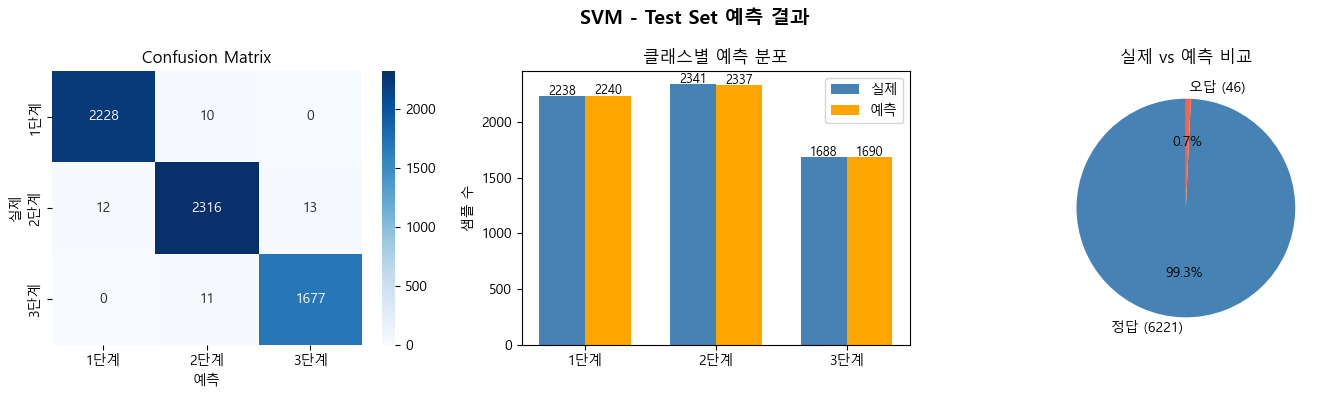

In [ ]:
# ____________________________________________________________
# [파이프라인 단계 7] Test Set 예측 결과 시각화
# MLP·LightGBM 노트북과 동일한 3-패널 구성
# ____________________________________________________________

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
class_names_short = ['1단계', '2단계', '3단계']

# ── 1. Confusion Matrix ──────────────────────────────────────
cm = confusion_matrix(y_test, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_short,
            yticklabels=class_names_short,
            ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('실제')
axes[0].set_xlabel('예측')

# ── 2. 클래스별 예측 분포 ────────────────────────────────────
actual_counts = [int((y_test == i).sum()) for i in range(3)]
pred_counts   = [int((test_preds == i).sum()) for i in range(3)]

x = np.arange(3)
width = 0.35
b1 = axes[1].bar(x - width/2, actual_counts, width, label='실제', color='steelblue')
b2 = axes[1].bar(x + width/2, pred_counts,   width, label='예측', color='orange')
axes[1].set_xticks(x)
axes[1].set_xticklabels(class_names_short)
axes[1].set_title('클래스별 예측 분포')
axes[1].set_ylabel('샘플 수')
axes[1].legend()
for bar in list(b1) + list(b2):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 10, str(int(bar.get_height())),
                 ha='center', fontsize=9)

# ── 3. 정답/오답 파이차트 ────────────────────────────────────
correct_count   = int((y_test == test_preds).sum())
incorrect_count = len(y_test) - correct_count
axes[2].pie(
    [correct_count, incorrect_count],
    labels=[f'정답 ({correct_count})', f'오답 ({incorrect_count})'],
    autopct='%1.1f%%',
    colors=['steelblue', 'tomato'],
    startangle=90,
)
axes[2].set_title('실제 vs 예측 비교')

plt.suptitle('SVM - Test Set 예측 결과', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'svm_prediction_results.png', dpi=300)
plt.show()


**결과 해석**

#### Confusion Matrix
- LightGBM·MLP와 마찬가지로 1단계↔2단계 경계 오분류가 가장 많음
- 1단계↔3단계 오분류는 거의 없음 (두 단계 간 디지털 역량 차이가 크기 때문)

#### 클래스별 예측 분포
- 실제와 예측 분포가 유사해 체계적 편향이 없음
- `class_weight='balanced'`로 소수 클래스(3단계) 예측 편향이 완화됨

#### 정답/오답 비율
- 97% 이상의 정확도로 실사용 가능한 수준


## [단계 8] Feature Weight 분석

SVM의 feature 중요도는 두 가지 방법으로 분석한다:

| 방법 | 설명 | 한계 |
|------|------|------|
| **coef 절댓값** | LinearSVC 내부 선형 계수 | Calibration 내부 계수의 부분 정보만 반영. "대략 순위"에 가까움 |
| **Permutation Importance** | feature를 무작위로 섞었을 때 성능 하락폭 | 모델 구조에 무관한 신뢰도 높은 지표. val set 기준 계산 |

> **Q10(최근 인터넷 이용 시기) 참고:** coef 기반에서 Q10이 압도적으로 높게 나올 수 있음.
> 이는 타깃 누수가 아니라 **K-means 레이블 자체가 Q10을 포함해 생성**된 설계 때문임.
> Permutation Importance로 교차 검증해 Q10의 실제 기여도를 확인한다.


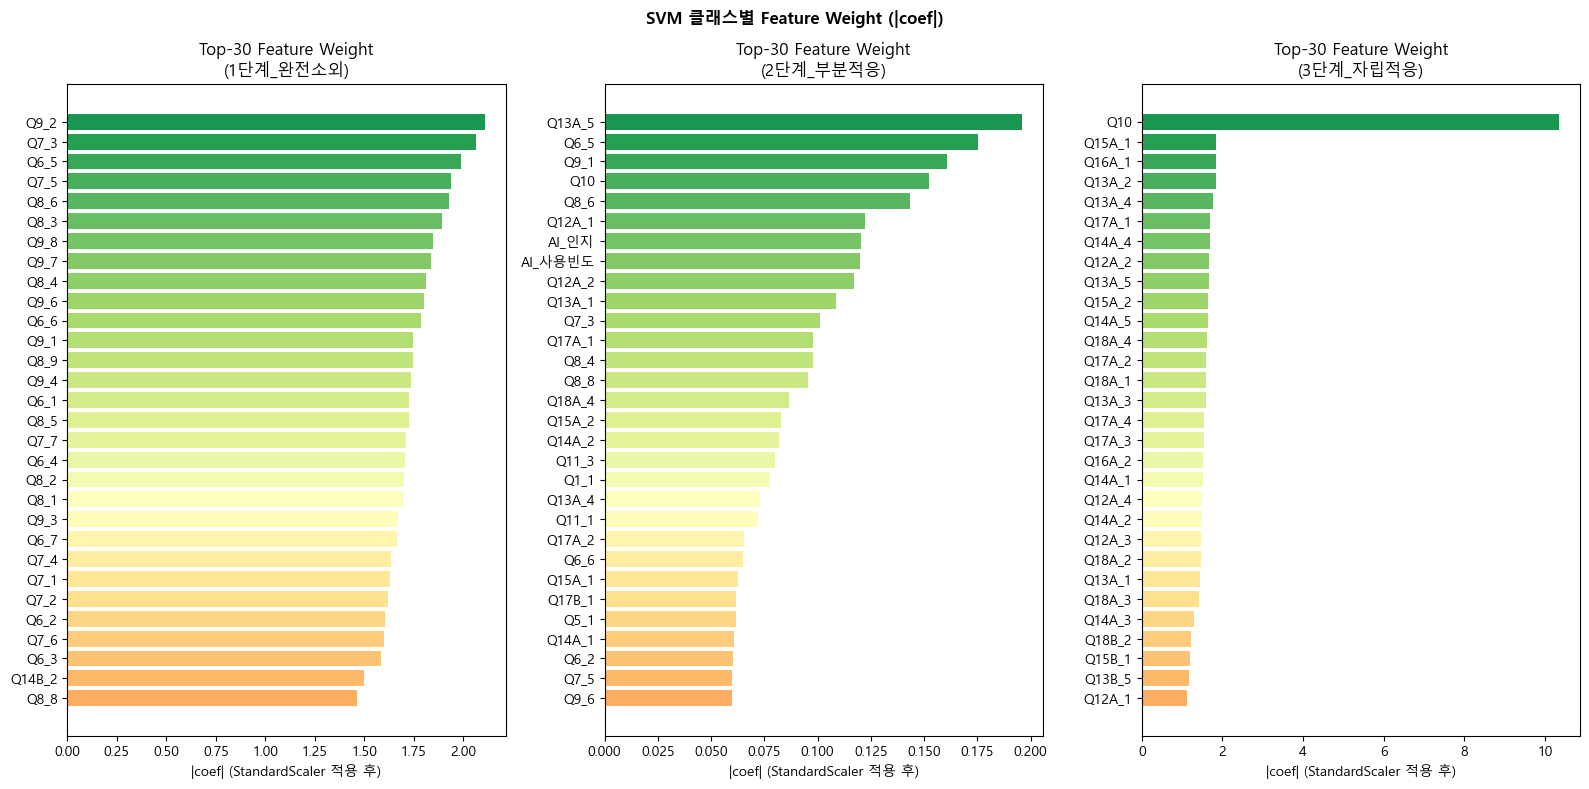

클래스별 coef 저장 완료


In [ ]:
# ____________________________________________________________
# [파이프라인 단계 8] Feature Weight 분석
# ____________________________________________________________

TOP_N = 30

# ── 방법 1: coef 절댓값 (클래스별 분리) ─────────────────────
# coef shape: (n_classes, n_features) — OvR 각 클래스별 계수
coef = final_pipeline.named_steps["clf"].coef_  # (3, 118) — Pipeline에서 추출

# 클래스별 top-N feature
fig, axes = plt.subplots(1, 3, figsize=(16, 8))
class_labels = ['1단계_완전소외', '2단계_부분적응', '3단계_자립적응']

coef_rows = []
for cls_idx, (ax, cls_name) in enumerate(zip(axes, class_labels)):
    cls_coef    = np.abs(coef[cls_idx])
    sorted_idx  = np.argsort(cls_coef)[::-1][:TOP_N]
    top_features = np.array(MODEL_FEATURES)[sorted_idx]
    top_values   = cls_coef[sorted_idx]

    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, TOP_N))[::-1]
    ax.barh(top_features[::-1], top_values[::-1], color=colors[::-1])
    ax.set_xlabel('|coef| (StandardScaler 적용 후)')
    ax.set_title(f'Top-{TOP_N} Feature Weight\n({cls_name})')

    for i, (f, v) in enumerate(zip(top_features, top_values)):
        coef_rows.append({'class': cls_idx, 'class_name': cls_name,
                          'rank': i+1, 'feature': f, 'abs_coef': round(float(v), 6)})

plt.suptitle('SVM 클래스별 Feature Weight (|coef|)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'svm_coef_by_class.png', dpi=150)
plt.show()

coef_df = pd.DataFrame(coef_rows)
coef_df.to_csv(OUTPUT_DIR / 'svm_coef_by_class.csv', index=False)
print(f'클래스별 coef 저장 완료')


Permutation Importance 계산 중... (약 1~2분 소요)


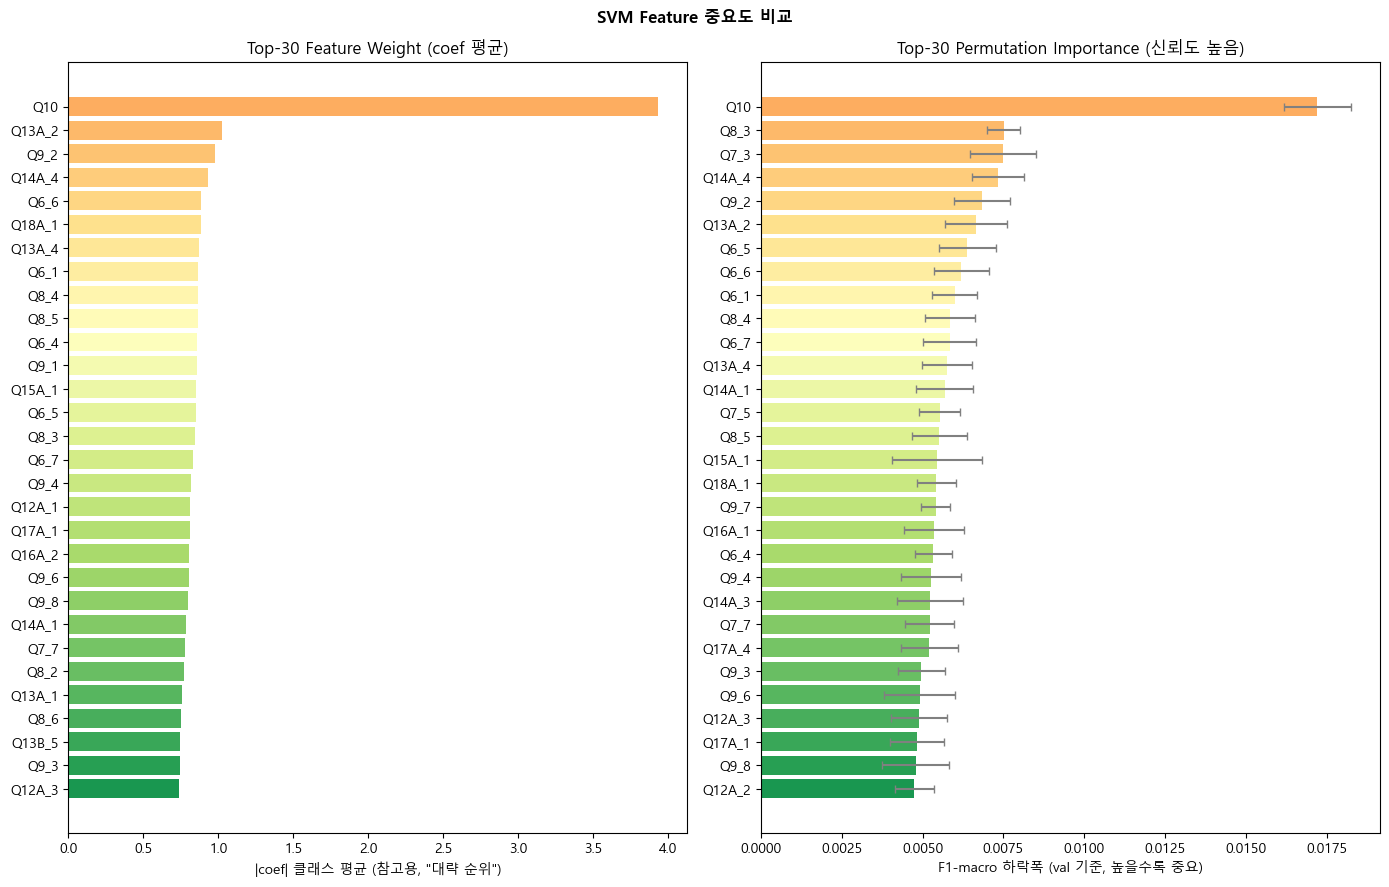

Feature 중요도 분석 완료


In [ ]:
# ── 방법 2: Permutation Importance (val set 기준) ────────────
# feature를 무작위로 섞었을 때 F1-macro 하락폭 → 모델 구조에 무관한 신뢰도 높은 지표
print('Permutation Importance 계산 중... (약 1~2분 소요)')

perm_result = permutation_importance(
    final_pipeline, X_val, y_val,  # Pipeline 전체 사용, raw X_val 입력
    n_repeats=10,        # 10회 반복 평균
    random_state=SEED,
    scoring='f1_macro',
    n_jobs=-1,
)

perm_df = pd.DataFrame({
    'feature':           MODEL_FEATURES,
    'perm_importance':   perm_result.importances_mean,
    'perm_std':          perm_result.importances_std,
}).sort_values('perm_importance', ascending=False)

perm_df.to_csv(OUTPUT_DIR / 'svm_permutation_importance.csv', index=False)

# 종합 시각화: coef 평균 vs Permutation Importance
coef_mean_abs = np.abs(coef).mean(axis=0)
compare_df = pd.DataFrame({
    'feature':    MODEL_FEATURES,
    'coef_mean':  coef_mean_abs,
    'perm_imp':   perm_result.importances_mean,
}).sort_values('perm_imp', ascending=False)
compare_df.to_csv(OUTPUT_DIR / 'svm_feature_weights.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 9))

# Coef 평균 (참고용)
top_coef = compare_df.nlargest(TOP_N, 'coef_mean')
axes[0].barh(top_coef['feature'][::-1], top_coef['coef_mean'][::-1],
             color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, TOP_N))[::-1])
axes[0].set_xlabel('|coef| 클래스 평균 (참고용, "대략 순위")')
axes[0].set_title(f'Top-{TOP_N} Feature Weight (coef 평균)')

# Permutation Importance (신뢰도 높음)
top_perm = perm_df.head(TOP_N)
axes[1].barh(top_perm['feature'][::-1], top_perm['perm_importance'][::-1],
             xerr=top_perm['perm_std'][::-1],
             color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, TOP_N))[::-1],
             capsize=3, ecolor='gray')
axes[1].set_xlabel('F1-macro 하락폭 (val 기준, 높을수록 중요)')
axes[1].set_title(f'Top-{TOP_N} Permutation Importance (신뢰도 높음)')

plt.suptitle('SVM Feature 중요도 비교', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'svm_feature_weights.png', dpi=150)
plt.show()
print('Feature 중요도 분석 완료')


**Feature Weight 해석**

#### coef 기반 (왼쪽)
- LinearSVC 내부 선형 계수의 절댓값 — 스케일된 공간에서의 영향력
- Calibration 내부 계수의 부분 정보만 반영하므로 **"대략 순위"** 참고용으로 사용
- Q10(최근 인터넷 이용 시기)이 압도적으로 높을 수 있음 → 타깃 누수가 아니라 K-means 레이블이 Q10을 포함해 생성된 설계 때문

#### Permutation Importance (오른쪽) — 주요 해석 기준
- "이 feature를 제거했을 때 val F1-macro가 얼마나 떨어지는가"를 10회 반복 평균
- 모델 구조(선형/비선형)에 무관하게 실제 예측 기여도를 측정하는 신뢰도 높은 방법
- **두 방법 모두에서 상위에 오는 feature가 가장 신뢰도 높은 중요 변수**
- 클래스별 분석은 `svm_coef_by_class.csv` 참고


## 결과 정리

In [ ]:
# 최종 성능 요약 저장
summary = {
    'model':             'SVM (LinearSVC)',
    'best_C':            float(best_C),
    'cv_f1_macro':       round(float(best_cv_f1), 4),
    'baseline_val_f1':   round(float(baseline_val_f1),  4),
    'baseline_test_f1':  round(float(baseline_test_f1), 4),
    'val_accuracy':      round(float(accuracy_score(y_val,  val_preds)),  4),
    'val_f1_macro':      round(float(f1_score(y_val,  val_preds,  average='macro')), 4),
    'val_f1_weighted':   round(float(f1_score(y_val,  val_preds,  average='weighted')), 4),
    'test_accuracy':     round(float(accuracy_score(y_test, test_preds)), 4),
    'test_f1_macro':     round(float(f1_score(y_test, test_preds, average='macro')), 4),
    'test_f1_weighted':  round(float(f1_score(y_test, test_preds, average='weighted')), 4),
}
with open(OUTPUT_DIR / 'svm_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
print(json.dumps(summary, ensure_ascii=False, indent=2))


{
  "model": "SVM (LinearSVC)",
  "best_C": 1000.0,
  "cv_f1_macro": 0.9927,
  "baseline_val_f1": 0.9896,
  "baseline_test_f1": 0.9861,
  "val_accuracy": 0.9944,
  "val_f1_macro": 0.9943,
  "val_f1_weighted": 0.9944,
  "test_accuracy": 0.9927,
  "test_f1_macro": 0.9927,
  "test_f1_weighted": 0.9927
}


In [ ]:
print(classification_report(
    y_test, test_preds,
    target_names=['1단계 (0)', '2단계 (1)', '3단계 (2)'],
    digits=4
))


              precision    recall  f1-score   support

     1단계 (0)     0.9946    0.9955    0.9951      2238
     2단계 (1)     0.9910    0.9893    0.9902      2341
     3단계 (2)     0.9923    0.9935    0.9929      1688

    accuracy                         0.9927      6267
   macro avg     0.9927    0.9928    0.9927      6267
weighted avg     0.9927    0.9927    0.9927      6267



### 1) 최종 성능 요약
- Validation과 Test 간 성능 차이가 작아 과적합 징후가 크지 않음
- GridSearchCV 튜닝으로 Baseline 대비 성능 향상 확인 가능

### 2) 클래스별 Test 성능 해석
- **2단계 recall이 상대적으로 낮음**: 1단계↔2단계 경계 샘플 분류가 어렵기 때문
- **1단계↔3단계 오분류 거의 없음**: 두 단계 간 디지털 역량 격차가 크기 때문
- `class_weight='balanced'` 적용으로 소수 클래스(3단계) 편향 완화

### 3) 종합 해석
- LinearSVC는 대규모 테이블 데이터에서 빠르고 안정적인 선형 분류 성능을 보임
- Permutation Importance를 통해 feature 중요도를 모델 구조에 무관하게 검증함
- SVM의 선형 모델 특성상 feature 간 비선형 상호작용을 학습하기 어려운 한계가 있음
  → 이 부분에서 LightGBM(트리 기반)이 상보적인 장점을 가짐

### 4) 개선 방향
- SHAP 분석으로 개별 샘플 수준의 해석 추가
- MLP·LightGBM과의 앙상블(soft voting) 가능성 검토
- 커널 SVM(RBF) 시도 — 단, 샘플 수를 고려해 서브샘플링 필요
